In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import datetime
from OSDE.LegendreExpSPDensity import LegExp, LegExpSPDensity, LegExpResult
from StocProcess.RBM import RBMTransProb, MakeRBMTransProbFunc
from QAE.RQAE import RQAE

In [2]:
# RBM parameters
c = -1
d = 1
x0 = 0.5 * (c + d)
t0 = 0
ts = np.concatenate([[0], np.linspace(0.2, 0.6, 5)])
mu = 0.5
sigma = 1.0
n_terms = 100

# approximation setting
maxDeg = 5
R = 12
K = 10

In [5]:
legExpResults = []
rqaeResults = []

for i in range(len(ts)-1):
    print(i, datetime.datetime.now())
    transProbFunc = MakeRBMTransProbFunc(ts[i+1], ts[i], c, d, mu, sigma, n_terms)

    if i == 0:
        densFunc = lambda x: transProbFunc(x, x0)
        legExpResult = LegExp(densFunc, maxDeg)
    else:
        legExpResult = LegExpSPDensity(legExpResults[i-1].fApp, transProbFunc, maxDeg)

    coefs = np.zeros(maxDeg+1)
    coefs[0] = 0.5
    for l in range(1, maxDeg+1):
        a = 0.5 * (legExpResult.coefs[l] / (l + 0.5) + 1)
        rqaeResult = RQAE(a, K, R)
        rqaeResults.append(rqaeResult.measOutDf)
        coefs[l] = (2 * rqaeResult.aEst -1) * (l + 0.5)
    legExpResults.append(LegExpResult(coefs))

0 2025-01-23 15:43:32.003640
1 2025-01-23 15:43:46.283630
2 2025-01-23 15:48:18.356706
3 2025-01-23 15:52:26.384519
4 2025-01-23 15:55:32.849066


In [6]:
xs = np.linspace(c, d, 100)

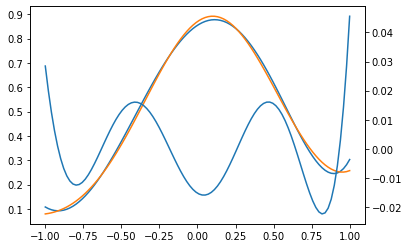

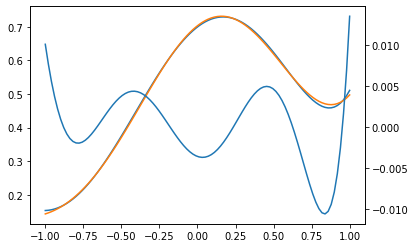

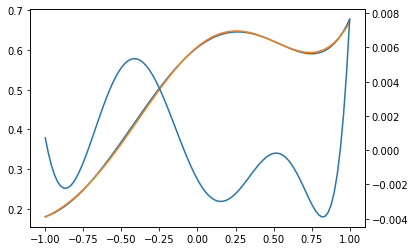

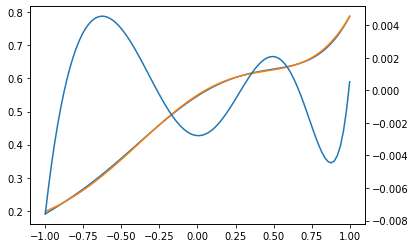

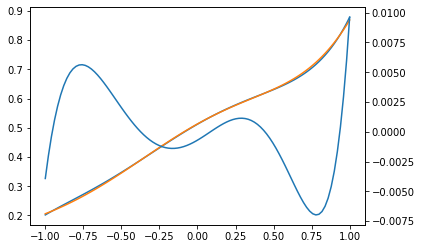

In [7]:
for i in range(len(ts)-1):
    pApp = np.array([legExpResults[i].fApp(x) for x in xs])
    pExa = np.array([RBMTransProb(x, ts[i+1], x0, t0, c, d, mu, sigma, n_terms) for x in xs])
    ax1 = plt.gca()
    ax1.plot(xs, pApp, label="app")
    ax1.plot(xs, pExa, label="exact")
    ax2 = ax1.twinx()
    ax2.plot(xs, pApp - pExa, label="diff")
    plt.show()